# Seattle Permit Predictor — Random Forest Model
*5-Fold Cross-Validated Random Forest | Target: `log(1 + totaldaysplanreview)`*

**Goal:** Given an address and project type, predict how long the permit approval process is likely to take for residential single family, attached accessory dwelling unit (ADU), and detached accessory dwelling unit (DADU) permits.

**Modeling population:** Completed permits from `master_dataset.csv` filtered to:
- `dwellingunittype` in: Detached Single-Family, Accessory Dwelling Attached, Accessory Dwelling Detached, and combination rows containing those types
- `statuscurrent` == Completed (permits with a full recorded review timeline)
- `app_year` < 2025 (2025 permits excluded — review clocks likely still running)

**Features used (all available at submission time):**
- `zone_family` — zoning prefix (NR, SF, LR, etc.)
- `log_estprojectcost` — log-transformed estimated project cost
- `log_housingunitsadded` — log-transformed housing units added
- `latitude`, `longitude` — spatial proxies for neighborhood effects

**Excluded by design:** `permittypedesc` and `permitclass` are now constant across the filtered population and carry no signal. `dwellingunittype` is used as a population filter only — the liaison flagged it as inaccurate for modeling. `housingcategory` is assigned post-build and unavailable at submission. All post-submission process fields (`daysplanreviewcity`, `numberreviewcycles`, etc.) are excluded to prevent data leakage.

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
import datetime
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
OUTPUT_DIR = r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output' + '\\'
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Filter Data

In [2]:
df_raw = pd.read_csv(f'{OUTPUT_DIR}master_dataset.csv')
print(f'Raw dataset: {df_raw.shape[0]:,} rows')

# Dwelling unit types that represent single family, ADU, and DADU permits
TARGET_DWELLING_TYPES = [
    'Detached Single-Family',
    'Accessory Dwelling Attached',
    'Accessory Dwelling Detached',
    'Accessory Dwelling Attached, Detached Single-Family',
    'Accessory Dwelling Detached, Detached Single-Family',
    'Accessory Dwelling Attached, Accessory Dwelling Detached',
    'Accessory Dwelling Attached, Accessory Dwelling Detached, Detached Single-Family',
    'Detached Single-Family, Accessory Dwelling Attached',
    'Detached Single-Family, Accessory Dwelling Detached',
    'Detached Single-Family, Accessory Dwelling Attached, Accessory Dwelling Detached',
    'Accessory Dwelling Detached, Accessory Dwelling Attached',
]

df = df_raw[
    df_raw['dwellingunittype'].isin(TARGET_DWELLING_TYPES) &
    (df_raw['statuscurrent'] == 'Completed') &
    (df_raw['app_year'] < 2025)
].copy()

print(f'After filtering  : {len(df):,} rows')
print(f'\nDwelling unit type breakdown:')
print(df['dwellingunittype'].value_counts())
print(f'\nYear breakdown:')
print(df['app_year'].value_counts().sort_index())
print(f'\nReview time stats (days):')
print(df['totaldaysplanreview'].describe().round(1))

Raw dataset: 14,201 rows
After filtering  : 3,543 rows

Dwelling unit type breakdown:
dwellingunittype
Accessory Dwelling Detached                                                         1374
Detached Single-Family                                                               672
Accessory Dwelling Attached, Detached Single-Family                                  672
Accessory Dwelling Attached                                                          495
Accessory Dwelling Detached, Detached Single-Family                                  140
Accessory Dwelling Attached, Accessory Dwelling Detached, Detached Single-Family     133
Accessory Dwelling Attached, Accessory Dwelling Detached                              31
Detached Single-Family, Accessory Dwelling Attached                                   23
Detached Single-Family, Accessory Dwelling Attached, Accessory Dwelling Detached       2
Accessory Dwelling Detached, Accessory Dwelling Attached                               1
Name: c

## 2. Feature Selection & Preprocessing

With the population now filtered to single family / accessory dwelling unit / detached accessory dwelling unit permits, `permittypedesc` and `permitclass` are effectively constant and dropped. The remaining submission-time features are zone family, project cost, units added, and coordinates.

In [3]:
CAT_FEATURES = ['zone_family']
NUM_FEATURES = ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = 'log_target'

for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown')

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print('Feature set:')
print(f'  Categorical : {CAT_FEATURES}')
print(f'  Numeric     : {NUM_FEATURES}')
print(f'\nX shape: {X.shape} | y shape: {y.shape}')
print(f'\nNull counts per feature:')
print(X.isnull().sum())

Feature set:
  Categorical : ['zone_family']
  Numeric     : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']

X shape: (3543, 5) | y shape: (3543,)

Null counts per feature:
zone_family              0
log_estprojectcost       4
log_housingunitsadded    0
latitude                 7
longitude                7
dtype: int64


In [4]:
cat_pipe = Pipeline([
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
], remainder='drop')

print('Preprocessor configured.')

Preprocessor configured.


## 3. Baseline Random Forest — 5-Fold Cross Validation

Initial model with 200 trees and default settings. Metrics computed on log scale (primary) and back-transformed to days (interpretable).

In [5]:
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', rf_baseline)
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_pipeline.fit(X_train, y_train)
    y_pred_log = model_pipeline.predict(X_val)

    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)

    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)

    fold_results.append({
        'fold': fold,
        'rmse_log': rmse_log,
        'mae_log': mae_log,
        'r2': r2,
        'rmse_days': rmse_days,
        'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

results_df = pd.DataFrame(fold_results)
print('\n--- 5-Fold Cross Validation Summary (Baseline Random Forest) ---')
print(results_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4))

Fold 1 | R²=0.2334 | RMSE(log)=0.6880 | MAE(days)=80.8
Fold 2 | R²=0.3178 | RMSE(log)=0.6000 | MAE(days)=70.4
Fold 3 | R²=0.3158 | RMSE(log)=0.6624 | MAE(days)=71.1
Fold 4 | R²=0.2960 | RMSE(log)=0.6497 | MAE(days)=74.0
Fold 5 | R²=0.2735 | RMSE(log)=0.6438 | MAE(days)=74.8

--- 5-Fold Cross Validation Summary (Baseline Random Forest) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.6488   0.4923  0.2873   115.0332   74.2091
std     0.0321   0.0255  0.0351     7.8140    4.1057


## 4. Hyperparameter Tuning — Grid Search

Grid search over key random forest hyperparameters using 5-fold cross validation. Scored on negative root mean squared error (log scale).

In [6]:
param_grid = {
    'rf__n_estimators': [200, 400],
    'rf__max_depth': [None, 20, 30],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features': ['sqrt', 0.5]
}

grid_search = GridSearchCV(
    estimator=Pipeline([
        ('prep', preprocessor),
        ('rf', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print('\nBest parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest cross validation RMSE (log scale): {-grid_search.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters:
  rf__max_depth: 30
  rf__max_features: sqrt
  rf__min_samples_leaf: 2
  rf__n_estimators: 400

Best cross validation RMSE (log scale): 0.6434


## 5. Tuned Random Forest — 5-Fold Cross Validation

Refit with best parameters. Out-of-fold predictions stored across all 5 folds for downstream residual analysis.

In [7]:
best_params = {k.replace('rf__', ''): v for k, v in grid_search.best_params_.items()}

rf_tuned = RandomForestRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tuned_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', rf_tuned)
])

tuned_results = []
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    tuned_pipeline.fit(X_train, y_train)
    y_pred_log = tuned_pipeline.predict(X_val)
    oof_preds[val_idx] = y_pred_log

    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)

    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)

    tuned_results.append({
        'fold': fold,
        'rmse_log': rmse_log,
        'mae_log': mae_log,
        'r2': r2,
        'rmse_days': rmse_days,
        'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

tuned_df = pd.DataFrame(tuned_results)
print('\n--- 5-Fold Cross Validation Summary (Tuned Random Forest) ---')
print(tuned_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4))

Fold 1 | R²=0.2548 | RMSE(log)=0.6783 | MAE(days)=82.1
Fold 2 | R²=0.3345 | RMSE(log)=0.5926 | MAE(days)=71.4
Fold 3 | R²=0.3174 | RMSE(log)=0.6617 | MAE(days)=73.3
Fold 4 | R²=0.3063 | RMSE(log)=0.6449 | MAE(days)=75.9
Fold 5 | R²=0.2827 | RMSE(log)=0.6397 | MAE(days)=76.4

--- 5-Fold Cross Validation Summary (Tuned Random Forest) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.6434   0.4942  0.2992   118.0039   75.8111
std     0.0322   0.0267  0.0311     7.1123    4.0734


## 6. Evaluation Plots

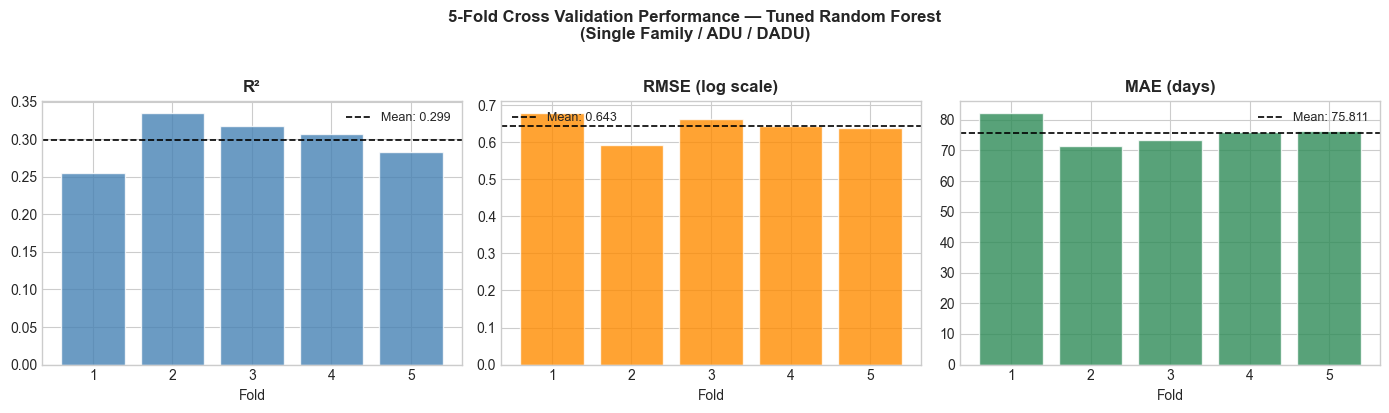

Saved: cv_metrics_per_fold.png


In [8]:
# --- Per-fold metrics bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('r2', 'R²', 'steelblue'), ('rmse_log', 'RMSE (log scale)', 'darkorange'), ('mae_days', 'MAE (days)', 'seagreen')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(tuned_df['fold'], tuned_df[col], color=color, alpha=0.8, edgecolor='white')
    mean_val = tuned_df[col].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.3f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(tuned_df['fold'])
    ax.legend(fontsize=9)

plt.suptitle('5-Fold Cross Validation Performance — Tuned Random Forest\n(Single Family / ADU / DADU)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}cv_metrics_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_metrics_per_fold.png')

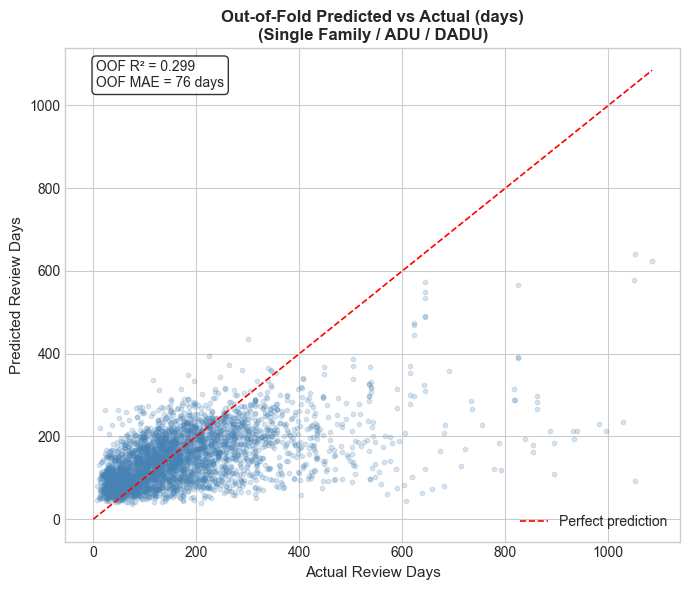

Saved: oof_pred_vs_actual.png


In [9]:
# --- Out-of-fold predicted vs actual ---
actual_days = np.expm1(y.values)
pred_days   = np.expm1(oof_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual_days, pred_days, alpha=0.2, s=10, color='steelblue', rasterized=True)
max_val = max(actual_days.max(), pred_days.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Review Days', fontsize=11)
ax.set_ylabel('Predicted Review Days', fontsize=11)
ax.set_title('Out-of-Fold Predicted vs Actual (days)\n(Single Family / ADU / DADU)', fontsize=12, fontweight='bold')
ax.legend()

overall_r2  = r2_score(y.values, oof_preds)
overall_mae = mean_absolute_error(actual_days, pred_days)
ax.text(0.05, 0.92, f'OOF R² = {overall_r2:.3f}\nOOF MAE = {overall_mae:.0f} days',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}oof_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: oof_pred_vs_actual.png')

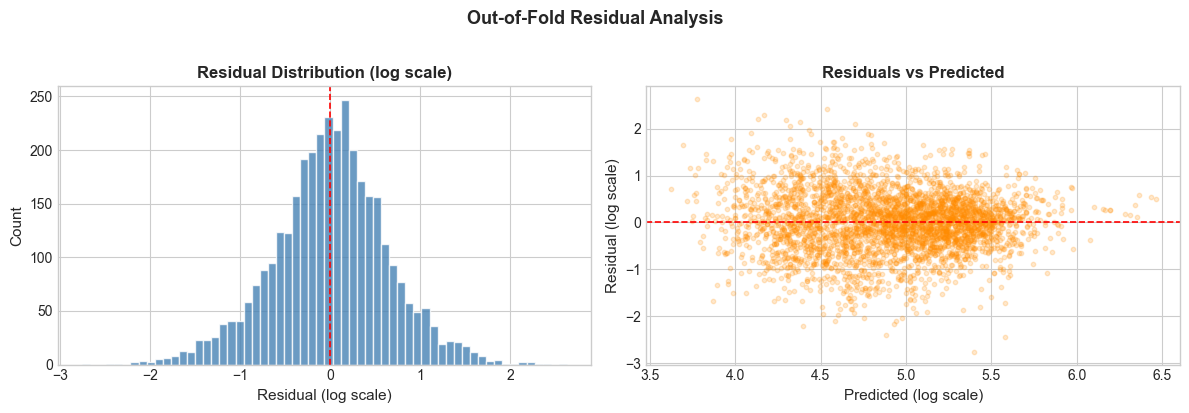

Saved: residual_analysis.png


In [10]:
# --- Residual analysis ---
residuals_log = y.values - oof_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals_log, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Residual (log scale)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Residual Distribution (log scale)', fontsize=12, fontweight='bold')

axes[1].scatter(oof_preds, residuals_log, alpha=0.2, s=10, color='darkorange', rasterized=True)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Predicted (log scale)', fontsize=11)
axes[1].set_ylabel('Residual (log scale)', fontsize=11)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.suptitle('Out-of-Fold Residual Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: residual_analysis.png')

## 7. Feature Importance

Model refit on full dataset for stable importance estimates.

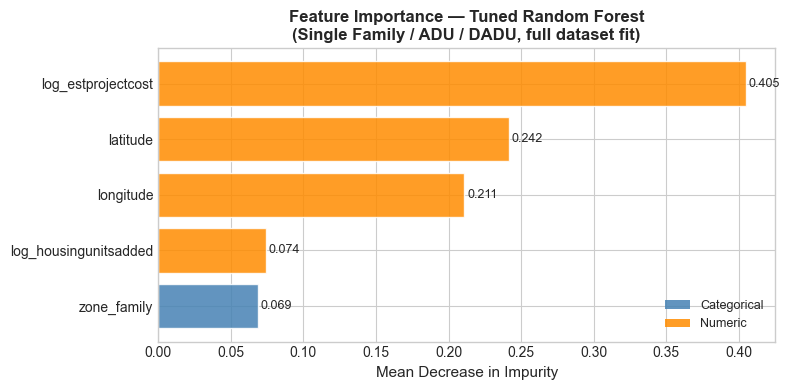

Saved: feature_importance.png

              feature  importance
   log_estprojectcost    0.404733
             latitude    0.241609
            longitude    0.210915
log_housingunitsadded    0.074018
          zone_family    0.068725


In [11]:
tuned_pipeline.fit(X, y)

feature_names = CAT_FEATURES + NUM_FEATURES
importances = tuned_pipeline.named_steps['rf'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if f in CAT_FEATURES else 'darkorange' for f in imp_df['feature']]
bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.85, label='Categorical'),
                   Patch(facecolor='darkorange', alpha=0.85, label='Numeric')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Feature Importance — Tuned Random Forest\n(Single Family / ADU / DADU, full dataset fit)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')
print()
print(imp_df.sort_values('importance', ascending=False).to_string(index=False))

## 8. Sanity Check — Predicted vs Actual by Zone and Dwelling Type

In [12]:
df_pred = df.copy()
for col in CAT_FEATURES:
    df_pred[col] = df_pred[col].fillna('Unknown')

df_pred['predicted_log']  = tuned_pipeline.predict(df_pred[ALL_FEATURES])
df_pred['predicted_days'] = np.expm1(df_pred['predicted_log'])
df_pred['actual_days']    = np.expm1(df_pred['log_target'])

print('=== Median Predicted vs Actual Days by Zone Family ===')
pz = df_pred.groupby('zone_family').agg(
    n=('actual_days', 'count'),
    actual_median=('actual_days', 'median'),
    predicted_median=('predicted_days', 'median')
).round(1).sort_values('actual_median', ascending=False)
print(pz.to_string())

print('\n=== Median Predicted vs Actual Days by Dwelling Unit Type ===')
pd_type = df_pred.groupby('dwellingunittype').agg(
    n=('actual_days', 'count'),
    actual_median=('actual_days', 'median'),
    predicted_median=('predicted_days', 'median')
).round(1).sort_values('actual_median', ascending=False)
print(pd_type.to_string())

=== Median Predicted vs Actual Days by Zone Family ===
                n  actual_median  predicted_median
zone_family                                       
NC              5          386.0             227.0
Other         391          231.0             224.7
LR            242          220.0             213.8
NR           1723          133.0             129.6
SF           1180          126.0             126.0
C1              1          109.0             101.4
MR              1           42.0              66.1

=== Median Predicted vs Actual Days by Dwelling Unit Type ===
                                                                                     n  actual_median  predicted_median
dwellingunittype                                                                                                       
Detached Single-Family, Accessory Dwelling Attached                                 23          241.0             188.0
Accessory Dwelling Attached, Accessory Dwelling Detached, Detac

## 9. Inference Function

Generates a prediction for a new single family, attached accessory dwelling unit, or detached accessory dwelling unit permit submission. Returns predicted days and an 80% confidence interval derived from individual tree predictions.

In [13]:
def predict_permit_review_time(
    zone_family: str,
    estprojectcost: float = None,
    housingunitsadded: float = None,
    latitude: float = None,
    longitude: float = None,
    pipeline=None,
    n_trees_ci: bool = True
) -> dict:
    """
    Predict permit review time for a single family / ADU / DADU submission.

    Parameters
    ----------
    zone_family       : e.g. 'SF', 'NR', 'LR' (see zone_family breakdown in section 1)
    estprojectcost    : estimated project cost in dollars (None = median imputed)
    housingunitsadded : number of units added (None = median imputed)
    latitude          : decimal degrees (None = median imputed)
    longitude         : decimal degrees (None = median imputed)
    n_trees_ci        : if True, derive 80% confidence interval from individual tree predictions

    Returns
    -------
    dict with keys: predicted_days, ci_low_days, ci_high_days, predicted_log
    """
    if pipeline is None:
        pipeline = tuned_pipeline

    log_cost  = np.log1p(estprojectcost)    if estprojectcost    is not None else np.nan
    log_units = np.log1p(housingunitsadded) if housingunitsadded is not None else np.nan

    row = pd.DataFrame([{
        'zone_family':           zone_family,
        'log_estprojectcost':    log_cost,
        'log_housingunitsadded': log_units,
        'latitude':              latitude  if latitude  is not None else np.nan,
        'longitude':             longitude if longitude is not None else np.nan,
    }])

    pred_log  = pipeline.predict(row)[0]
    pred_days = np.expm1(pred_log)

    result = {
        'predicted_days': round(pred_days, 1),
        'predicted_log': round(pred_log, 4)
    }

    if n_trees_ci:
        prep = pipeline.named_steps['prep']
        rf   = pipeline.named_steps['rf']
        X_t  = prep.transform(row)
        tree_preds = np.array([t.predict(X_t)[0] for t in rf.estimators_])
        result['ci_low_days']  = round(np.expm1(np.percentile(tree_preds, 10)), 1)
        result['ci_high_days'] = round(np.expm1(np.percentile(tree_preds, 90)), 1)

    return result


# --- Example predictions ---
examples = [
    {'zone_family': 'SF',  'estprojectcost': 500_000, 'housingunitsadded': 1, 'latitude': 47.65, 'longitude': -122.35},
    {'zone_family': 'NR',  'estprojectcost': 250_000, 'housingunitsadded': 1, 'latitude': 47.60, 'longitude': -122.32},
    {'zone_family': 'NR',  'estprojectcost': 150_000, 'housingunitsadded': 1, 'latitude': 47.62, 'longitude': -122.33},
    {'zone_family': 'LR',  'estprojectcost': 400_000, 'housingunitsadded': 2, 'latitude': 47.68, 'longitude': -122.34},
]

print('=== Example Predictions (Single Family / ADU / DADU) ===')
for ex in examples:
    result = predict_permit_review_time(**ex)
    print(f"\n  Zone={ex['zone_family']} | Cost=${ex.get('estprojectcost',0):,} | Units added={ex.get('housingunitsadded',0)}")
    print(f"    Predicted : {result['predicted_days']:.0f} days")
    if 'ci_low_days' in result:
        print(f"    80% CI    : {result['ci_low_days']:.0f} – {result['ci_high_days']:.0f} days")

=== Example Predictions (Single Family / ADU / DADU) ===

  Zone=SF | Cost=$500,000 | Units added=1
    Predicted : 145 days
    80% CI    : 71 – 273 days

  Zone=NR | Cost=$250,000 | Units added=1
    Predicted : 132 days
    80% CI    : 45 – 340 days

  Zone=NR | Cost=$150,000 | Units added=1
    Predicted : 106 days
    80% CI    : 50 – 230 days

  Zone=LR | Cost=$400,000 | Units added=2
    Predicted : 233 days
    80% CI    : 115 – 423 days


## 10. Save Model Weights

In [14]:
model_save_path = f'{OUTPUT_DIR}ModelWeights_RF_SF.joblib'
joblib.dump(tuned_pipeline, model_save_path)
print(f'Model saved: {model_save_path}')

Model saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\ModelWeights_RF_SF.joblib


## 11. Full Diagnostic Report

All outputs consolidated in one place for easy troubleshooting.

In [15]:
sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — RANDOM FOREST DIAGNOSTIC REPORT')
lines.append('  Scope: Single Family / ADU (Accessory Dwelling Unit) / DADU (Detached Accessory Dwelling Unit)')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Dataset ────────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] DATASET')
lines.append(sep2)
lines.append(f'  Rows in modeling population : {len(df):,}')
lines.append(f'  Filter: dwellingunittype in target list, statuscurrent=Completed, app_year < 2025')
lines.append(f'  Features (categorical)      : {CAT_FEATURES}')
lines.append(f'  Features (numeric)          : {NUM_FEATURES}')
lines.append(f'  Target                      : log(1 + totaldaysplanreview)')
lines.append('')
lines.append('  Null counts per feature:')
for col, n in X.isnull().sum().items():
    pct = n / len(X) * 100
    lines.append(f'    {col:<28} {n:>5}  ({pct:.1f}%)')
lines.append('')
lines.append('  Review time distribution (days):')
for stat, val in df['totaldaysplanreview'].describe().items():
    lines.append(f'    {stat:<8} {val:>8.1f}')

# ── 2. Baseline Cross Validation ──────────────────────────────────────────
lines.append('')
lines.append('[ 2 ] BASELINE RANDOM FOREST — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append('  n_estimators=200, all other params=default')
lines.append('')
lines.append(f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 60)
for _, row in results_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = results_df.drop('fold', axis=1).mean()
s = results_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 3. Grid Search ────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 3 ] HYPERPARAMETER TUNING — GRID SEARCH RESULTS')
lines.append(sep2)
lines.append(f'  Best cross validation RMSE (log scale): {-grid_search.best_score_:.4f}')
lines.append('  Best parameters:')
for k, v in grid_search.best_params_.items():
    lines.append(f'    {k:<30} {v}')
lines.append('')
lines.append('  Full grid results (mean_test_score = negative RMSE):')
cv_res = pd.DataFrame(grid_search.cv_results_)
cols_show = ['param_rf__n_estimators','param_rf__max_depth','param_rf__min_samples_leaf',
             'param_rf__max_features','mean_test_score','std_test_score','rank_test_score']
cv_res_show = cv_res[cols_show].sort_values('rank_test_score')
cv_res_show.columns = ['n_est','max_depth','min_leaf','max_feat','mean_neg_rmse','std','rank']
lines.append(f'  {cv_res_show.to_string(index=False)}')

# ── 4. Tuned Cross Validation ─────────────────────────────────────────────
lines.append('')
lines.append('[ 4 ] TUNED RANDOM FOREST — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append(f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 60)
for _, row in tuned_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = tuned_df.drop('fold', axis=1).mean()
s = tuned_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 5. Out-of-Fold Aggregate Metrics ──────────────────────────────────────
lines.append('')
lines.append('[ 5 ] OUT-OF-FOLD AGGREGATE METRICS')
lines.append(sep2)
oof_r2       = r2_score(y.values, oof_preds)
oof_rmse     = np.sqrt(mean_squared_error(y.values, oof_preds))
oof_mae      = mean_absolute_error(y.values, oof_preds)
oof_mae_days = mean_absolute_error(np.expm1(y.values), np.expm1(oof_preds))
residuals    = y.values - oof_preds
lines.append(f'  OOF R²              : {oof_r2:.4f}')
lines.append(f'  OOF RMSE (log)      : {oof_rmse:.4f}')
lines.append(f'  OOF MAE  (log)      : {oof_mae:.4f}')
lines.append(f'  OOF MAE  (days)     : {oof_mae_days:.1f}')
lines.append(f'  Residual mean       : {residuals.mean():.4f}  (bias check; ideal = 0)')
lines.append(f'  Residual std        : {residuals.std():.4f}')
lines.append(f'  Residual skewness   : {pd.Series(residuals).skew():.4f}')
lines.append(f'  Residual kurtosis   : {pd.Series(residuals).kurt():.4f}')

# ── 6. Feature Importance ─────────────────────────────────────────────────
lines.append('')
lines.append('[ 6 ] FEATURE IMPORTANCE (full-dataset fit, Mean Decrease in Impurity)')
lines.append(sep2)
for _, row in imp_df.sort_values('importance', ascending=False).iterrows():
    bar = '█' * int(row['importance'] * 100)
    lines.append(f'  {row["feature"]:<28}  {row["importance"]:.4f}  {bar}')

# ── 7. Sanity Check Tables ────────────────────────────────────────────────
lines.append('')
lines.append('[ 7 ] SANITY CHECK — MEDIAN PREDICTED vs ACTUAL DAYS')
lines.append(sep2)
lines.append('  By Zone Family:')
lines.append(f'  {pz.to_string()}')
lines.append('')
lines.append('  By Dwelling Unit Type:')
lines.append(f'  {pd_type.to_string()}')

# ── 8. Example Predictions ────────────────────────────────────────────────
lines.append('')
lines.append('[ 8 ] EXAMPLE INFERENCE PREDICTIONS')
lines.append(sep2)
for ex in examples:
    result = predict_permit_review_time(**ex)
    lines.append(f"  Zone={ex['zone_family']} | Cost=${ex.get('estprojectcost',0):,} | Units added={ex.get('housingunitsadded',0)}")
    lines.append(f"    Predicted : {result['predicted_days']:.0f} days")
    if 'ci_low_days' in result:
        lines.append(f"    80% CI    : {result['ci_low_days']:.0f} – {result['ci_high_days']:.0f} days")
    lines.append('')

# ── 9. Saved Artifacts ────────────────────────────────────────────────────
lines.append('[ 9 ] SAVED ARTIFACTS')
lines.append(sep2)
for a in [
    'ModelWeights_RF.joblib      — fitted pipeline (preprocessor + tuned random forest)',
    'cv_metrics_per_fold.png     — per-fold R², RMSE, MAE bar charts',
    'oof_pred_vs_actual.png      — out-of-fold predicted vs actual scatter',
    'residual_analysis.png       — residual histogram and residuals vs predicted',
    'feature_importance.png      — Mean Decrease in Impurity feature importance bar chart',
    'DiagnosticReport_RF.txt     — this report',
]:
    lines.append(f'  {a}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

report_path = f'{OUTPUT_DIR}DiagnosticReport_RF.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')

  SEATTLE PERMIT PREDICTOR — RANDOM FOREST DIAGNOSTIC REPORT
  Scope: Single Family / ADU (Accessory Dwelling Unit) / DADU (Detached Accessory Dwelling Unit)
  Generated: 2026-05-12 18:57:09

[ 1 ] DATASET
----------------------------------------------------------------------
  Rows in modeling population : 3,543
  Filter: dwellingunittype in target list, statuscurrent=Completed, app_year < 2025
  Features (categorical)      : ['zone_family']
  Features (numeric)          : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
  Target                      : log(1 + totaldaysplanreview)

  Null counts per feature:
    zone_family                      0  (0.0%)
    log_estprojectcost               4  (0.1%)
    log_housingunitsadded            0  (0.0%)
    latitude                         7  (0.2%)
    longitude                        7  (0.2%)

  Review time distribution (days):
    count      3543.0
    mean        175.6
    std         135.6
    min           8.0


UnicodeEncodeError: 'charmap' codec can't encode characters in position 6331-6370: character maps to <undefined>